In [8]:
%run geminiGeneratedHelper.ipynb 

Generated A-scan. Target peak found at range bin: 4


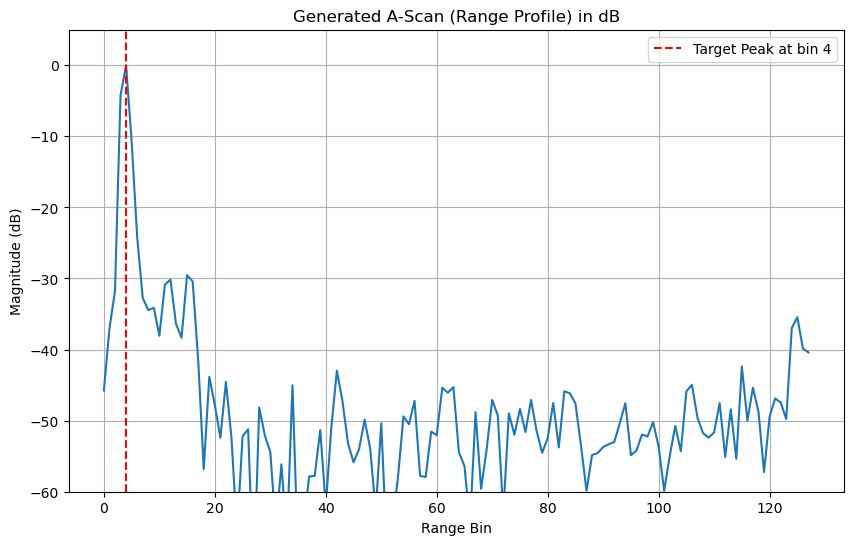

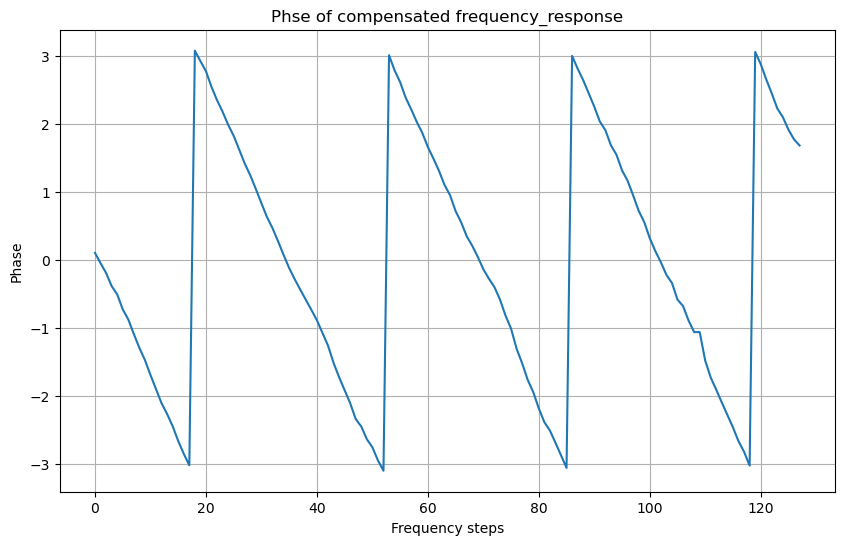

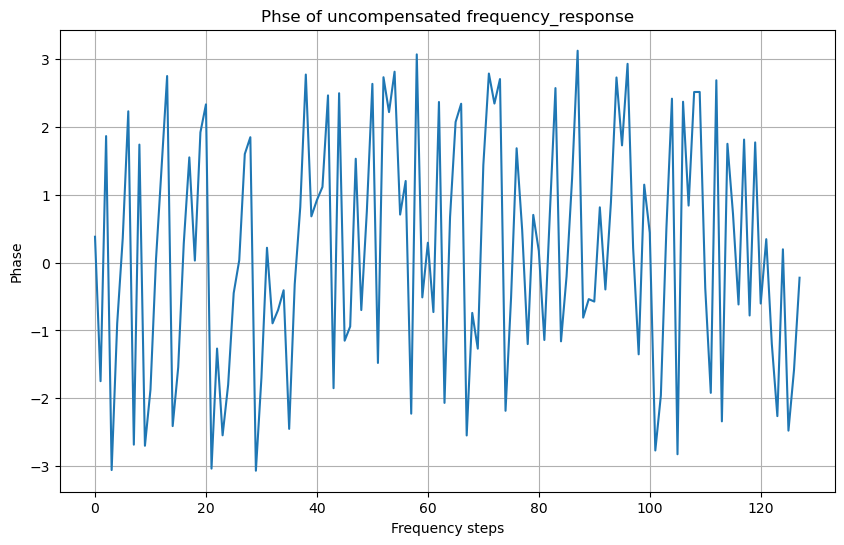

signal_power:  0.20134530410537194
average_noise_power:  1.964798352074702e-05


np.float64(40.10623497876618)

In [9]:
SAMPLING_RATE = 10e6    # 5 MHz
CHIRP_BANDWIDTH = 2e6  # 1 MHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/'
prefix = 'test_channel_extractor'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile, calibrated_channel_response, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

plotResults(ascan_profile, calibrated_channel_response, echo_response)

calculate_snr(ascan_profile)

Generated A-scan. Target peak found at range bin: 4


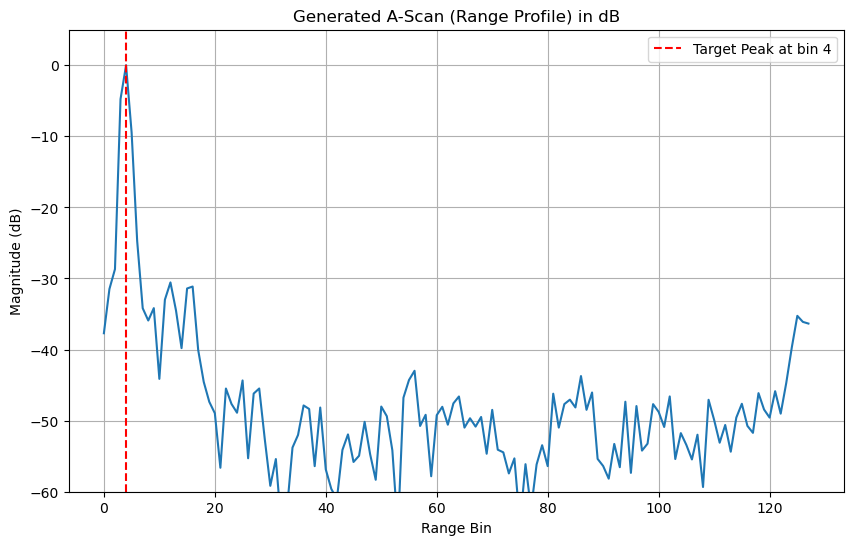

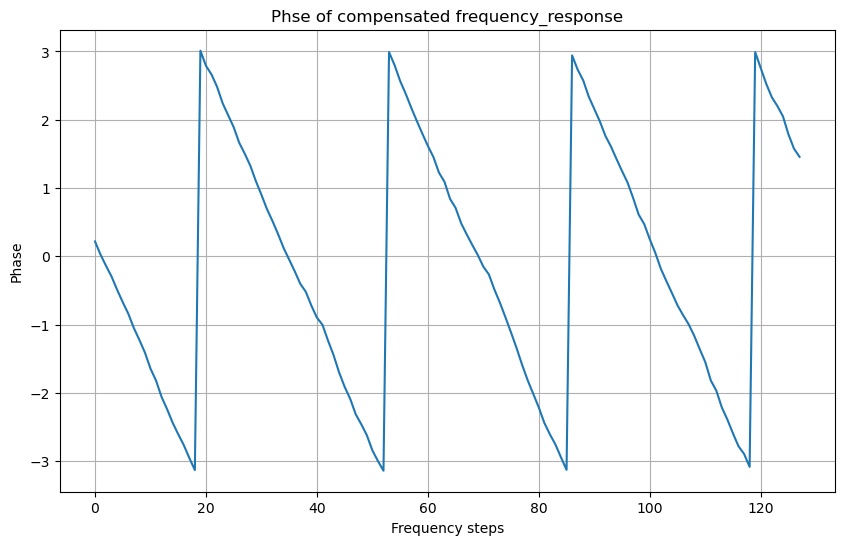

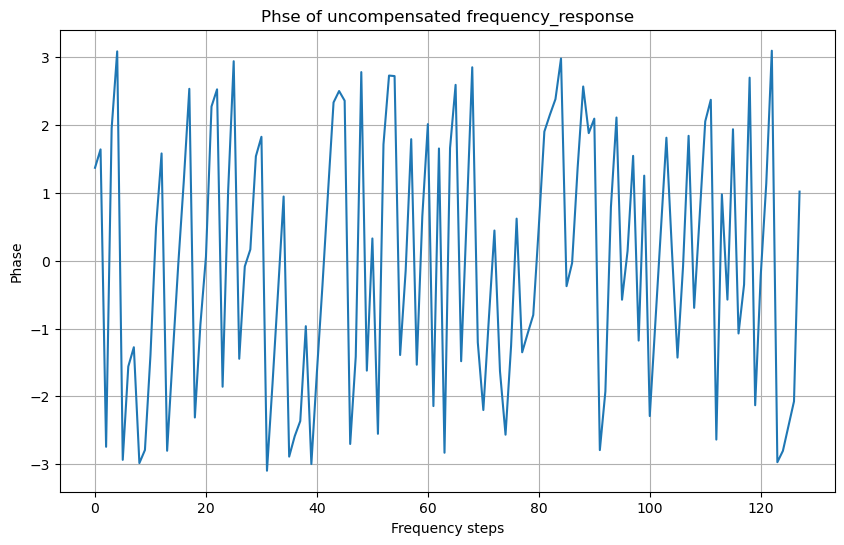

signal_power:  24.40054977651584
average_noise_power:  0.0023723831043808556


np.float64(40.122147890751194)

signal_power:  3.936488602426718e-05
average_noise_power:  9.780390531188117e-07
Baseline Single-Pulse SNR: 16.05 dB
signal_power:  4.789656158185674e-05
average_noise_power:  4.770995091684713e-07
  - Stacks (N=   2): Stacked SNR= 20.02 dB, Gain=  3.97 dB
signal_power:  4.923371036094641e-05
average_noise_power:  2.75045599278259e-07
  - Stacks (N=   4): Stacked SNR= 22.53 dB, Gain=  6.48 dB
signal_power:  4.808867615863202e-05
average_noise_power:  1.4807358934134464e-07
  - Stacks (N=   8): Stacked SNR= 25.12 dB, Gain=  9.07 dB
signal_power:  5.027147025216215e-05
average_noise_power:  8.121353738889492e-08
  - Stacks (N=  16): Stacked SNR= 27.92 dB, Gain= 11.87 dB
signal_power:  4.916947912409566e-05
average_noise_power:  7.122006143147019e-08
  - Stacks (N=  32): Stacked SNR= 28.39 dB, Gain= 12.34 dB
signal_power:  5.370251089912444e-05
average_noise_power:  5.166848480343285e-08
  - Stacks (N=  64): Stacked SNR= 30.17 dB, Gain= 14.12 dB
signal_power:  5.546642870405399e-05
averag

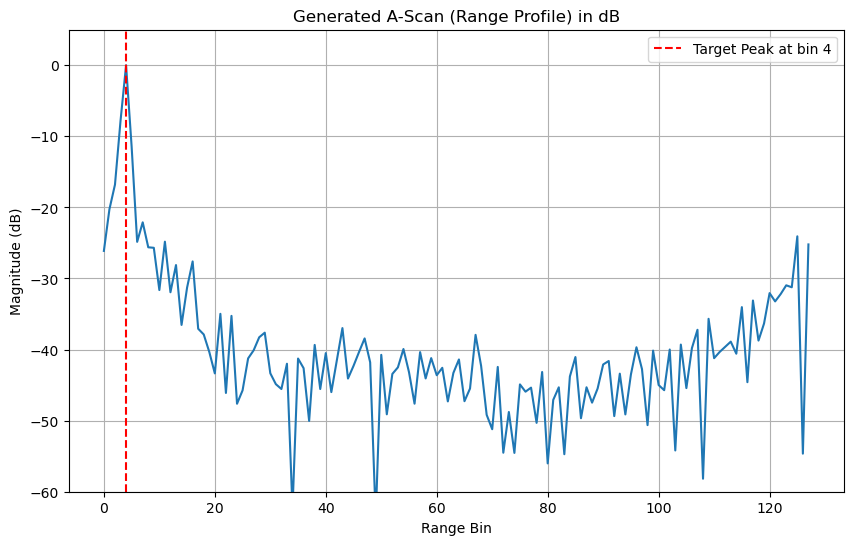

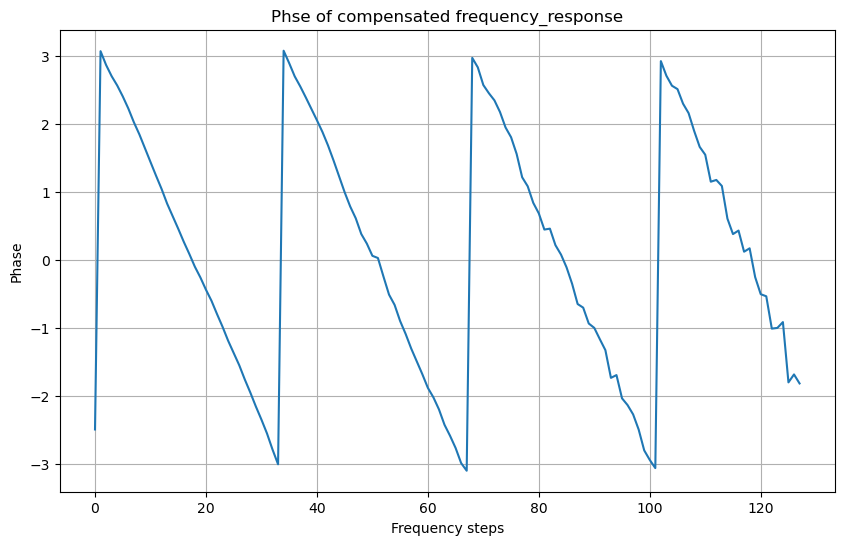

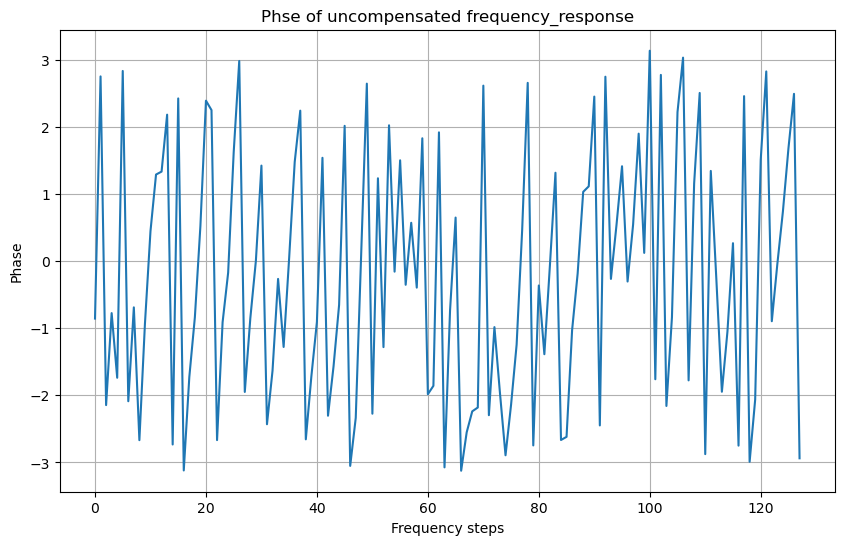

In [4]:
SAMPLING_RATE = 10e6    # 5 MHz
CHIRP_BANDWIDTH = 2e6  # 1 MHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/loop_back_chirp/'
prefix = ''

channel_responses = []
for i in range(512):
    fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
    fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
    rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)
    
    # --- Generate the A-scan using the function ---
    ascan_profile, calibrated_channel_response, echo_response = generate_ascan_from_lfm(
        echo_signals=rx_samples,
        reference_signals=ref_samples,
        num_steps=num_steps,
        step_length=burst_len,
        chirp_bandwidth=CHIRP_BANDWIDTH,
        sampling_rate_hz=SAMPLING_RATE
    )
    channel_responses.append(calibrated_channel_response)
channel_responses = np.array(channel_responses)

actual_stack_sizes, processing_gains_db, a_scan_stacked, stacked_freq_response = calculate_processing_gain(channel_responses)

plotResults(a_scan_stacked, stacked_freq_response, echo_response)